In [1]:
import json
import pandas as pd
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, XSD, OWL
import re

### --- Define Namespaces ---

In [2]:
# Define Wikidata namespaces
WIKIDATA = Namespace("http://www.wikidata.org/entity/")
WDT = Namespace("http://www.wikidata.org/prop/direct/")
SCHEMA = Namespace("http://schema.org/")
SPOTIFY = Namespace("http://example.org/spotify/")  # Custom namespace for Spotify data

# Initialize graph
g = Graph()
g.bind("wd", WIKIDATA)
g.bind("wdt", WDT)
g.bind("schema", SCHEMA)
g.bind("spotify", SPOTIFY)
g.bind("rdfs", RDFS)
g.bind("xsd", XSD)
g.bind("owl", OWL) # Bind OWL namespace


# --- NEW: Define Custom Classes ---
# These will be the more suggestive class names
CLASS_PERSON = WIKIDATA["Q5"]
CLASS_ALBUM = WIKIDATA["Q482994"]
CLASS_SONG = WIKIDATA["Q7366"]
CLASS_COUNTRY = WIKIDATA["Q45"]

# Add RDFS labels for these new classes to make them readable in Protege
g.add((CLASS_PERSON, RDF.type, OWL.Class))
g.add((CLASS_PERSON, RDFS.label, Literal("Person")))
g.add((CLASS_ALBUM, RDF.type, OWL.Class))
g.add((CLASS_ALBUM, RDFS.label, Literal("Album")))
g.add((CLASS_SONG, RDF.type, OWL.Class))
g.add((CLASS_SONG, RDFS.label, Literal("Song")))
g.add((CLASS_COUNTRY, RDF.type, OWL.Class)) 
g.add((CLASS_COUNTRY, RDFS.label, Literal("Country", lang="en"))) 

# Optionally, you can assert equivalence to Wikidata classes if you want to maintain that link
# g.add((CLASS_PERSON, OWL.equivalentClass, WIKIDATA["Q5"]))
# g.add((CLASS_ALBUM, OWL.equivalentClass, WIKIDATA["Q482994"]))
# g.add((CLASS_SONG, OWL.equivalentClass, WIKIDATA["Q7302866"]))

<Graph identifier=Nb24e1f05ed124fa9a50da52a4895e5f0 (<class 'rdflib.graph.Graph'>)>

### --- Load Data Files ---

In [3]:
print("Loading data files...")

# Load JSON files
try:
    with open("artists_data.json", "r", encoding="utf-8") as f:
        artists_data = json.load(f)
    print("- artists_data.json loaded.")
except FileNotFoundError:
    print("Error: artists_data.json not found. Please ensure the file is available.")
    artists_data = [] # Initialize as empty to prevent further errors

try:
    with open("artists_music_data.json", "r", encoding="utf-8") as f:
        artists_music_data = json.load(f)
    print("- artists_music_data.json loaded.")
except FileNotFoundError:
    print("Error: artists_music_data.json not found. Please ensure the file is available.")
    artists_music_data = [] # Initialize as empty to prevent further errors

try:
    with open("artists_top_355_data.json", "r", encoding="utf-8") as f:
        top_artists_data = json.load(f)
    print("- artists_top_355_data.json loaded.")
except FileNotFoundError:
    print("Error: artists_top_355_data.json not found. Please ensure the file is available.")
    top_artists_data = [] # Initialize as empty to prevent further errors


# Load CSV files directly from disk
csv_files = {
    "artists_country_of_citizenship.csv": None,
    "artists_name_id_wikidata.csv": None,
    "countries_data.csv": None
}

for file_name in csv_files:
    try:
        csv_files[file_name] = pd.read_csv(file_name)
        print(f"- {file_name} loaded.")
    except FileNotFoundError:
        print(f"Error: {file_name} not found. Please ensure the file is in the correct directory.")
    except Exception as e:
        print(f"Error loading {file_name}: {e}. Trying with 'latin1' encoding.")
        try:
            csv_files[file_name] = pd.read_csv(file_name, encoding='latin1')
            print(f"- {file_name} loaded with 'latin1' encoding.")
        except Exception as e_latin1:
            print(f"Error loading {file_name} with 'latin1' encoding: {e_latin1}. Skipping.")

artists_country_of_citizenship_df = csv_files["artists_country_of_citizenship.csv"]
artists_name_id_wikidata_df = csv_files["artists_name_id_wikidata.csv"]
countries_data_df = csv_files["countries_data.csv"]

Loading data files...
- artists_data.json loaded.
- artists_music_data.json loaded.
- artists_top_355_data.json loaded.
- artists_country_of_citizenship.csv loaded.
- artists_name_id_wikidata.csv loaded.
- countries_data.csv loaded.


### --- Create Lookup Dictionaries ---

In [4]:
print("\nCreating lookup dictionaries...")

# name_to_qid: Artist Name to Wikidata QID
name_to_qid = {}
if artists_name_id_wikidata_df is not None and not artists_name_id_wikidata_df.empty:
    if 'name' in artists_name_id_wikidata_df.columns and 'Wikidata_QID' in artists_name_id_wikidata_df.columns:
        name_to_qid = dict(zip(artists_name_id_wikidata_df["name"], artists_name_id_wikidata_df["Wikidata_QID"]))
        print("- name_to_qid created from artists_name_id_wikidata.csv.")
    else:
        print("Warning: 'name' or 'Wikidata_QID' column not found in artists_name_id_wikidata.csv. Skipping name_to_qid creation.")
else:
    print("Warning: artists_name_id_wikidata.csv was not loaded or is empty. Wikidata QIDs for artists will be limited.")

# country_to_qid: Country Name to Wikidata QID
country_to_qid = {}
if countries_data_df is not None and not countries_data_df.empty:
    if 'Country Name' in countries_data_df.columns and 'Wikidata QID' in countries_data_df.columns:
        country_to_qid = dict(zip(countries_data_df["Country Name"], countries_data_df["Wikidata QID"]))
        print("- country_to_qid created from countries_data.csv.")
    else:
        print("Warning: 'Country Name' or 'Wikidata QID' column not found in countries_data.csv. Skipping country_to_qid creation.")
else:
    print("Warning: countries_data.csv was not loaded or is empty. Country QIDs will be limited.")

# --- Master Artist URI and Label Mapping ---
# This dictionary will map spotify_id -> canonical_spotify_uri
# And spotify_id -> preferred_name
canonical_artist_uris_by_id = {} # Maps spotify_id -> canonical_uri
spotify_id_to_preferred_name = {} # Maps spotify_id -> preferred_name

print("\nBuilding master artist URI and label mapping...")

# 1. Populate from top_artists_data (most reliable Spotify IDs and names)
for artist in top_artists_data:
    artist_name = artist.get('name')
    artist_id = artist.get('id')
    if artist_id:
        canonical_uri = SPOTIFY[f"artist/{artist_id}"]
        canonical_artist_uris_by_id[artist_id] = canonical_uri
        if artist_name:
            spotify_id_to_preferred_name[artist_id] = artist_name

# 2. Populate from artists_music_data (captures all artists with music, including featured)
for artist_music_entry in artists_music_data:
    main_artist_name = artist_music_entry.get('artist_name')
    main_artist_id = artist_music_entry.get('artist_id')
    if main_artist_id:
        canonical_uri = SPOTIFY[f"artist/{main_artist_id}"]
        if main_artist_id not in canonical_artist_uris_by_id:
            canonical_artist_uris_by_id[main_artist_id] = canonical_uri
        if main_artist_id not in spotify_id_to_preferred_name and main_artist_name:
            spotify_id_to_preferred_name[main_artist_id] = main_artist_name

    for album in artist_music_entry.get("albums", []):
        for track in album.get("tracks", []):
            for performer_info in track.get("artists", []):
                performer_name = performer_info.get('artist_name')
                performer_id = performer_info.get('artist_id')
                if performer_id:
                    canonical_uri = SPOTIFY[f"artist/{performer_id}"]
                    if performer_id not in canonical_artist_uris_by_id:
                        canonical_artist_uris_by_id[performer_id] = canonical_uri
                    if performer_id not in spotify_id_to_preferred_name and performer_name:
                        spotify_id_to_preferred_name[performer_id] = performer_name


# 3. Populate from artists_data (for biographical details, linking to canonical URI)
artist_name_to_spotify_id_lookup = {artist['name']: artist['id'] for artist in top_artists_data if 'name' in artist and 'id' in artist}

for artist_info in artists_data:
    artist_name = artist_info.get('name')
    if artist_name:
        spotify_id = artist_name_to_spotify_id_lookup.get(artist_name)
        if spotify_id:
            canonical_uri = SPOTIFY[f"artist/{spotify_id}"]
            if spotify_id not in canonical_artist_uris_by_id:
                canonical_artist_uris_by_id[spotify_id] = canonical_uri
            if spotify_id not in spotify_id_to_preferred_name:
                spotify_id_to_preferred_name[spotify_id] = artist_name
        else:
            # Fallback for artists in artists_data without a Spotify ID in other sources
            clean_name = re.sub(r'[^\w\s-]', '', artist_name).replace(' ', '_')
            pseudo_spotify_id = f"name_based_{clean_name}"
            canonical_uri = SPOTIFY[f"artist/{clean_name}"]
            if pseudo_spotify_id not in canonical_artist_uris_by_id:
                canonical_artist_uris_by_id[pseudo_spotify_id] = canonical_uri
                spotify_id_to_preferred_name[pseudo_spotify_id] = artist_name


print(f"Master artist URI and label mapping built. Total unique artists mapped: {len(canonical_artist_uris_by_id)}")


Creating lookup dictionaries...
- name_to_qid created from artists_name_id_wikidata.csv.
- country_to_qid created from countries_data.csv.

Building master artist URI and label mapping...
Master artist URI and label mapping built. Total unique artists mapped: 8837


### Countries

In [5]:
continent_qid_map = {
    "Africa": "Q15",
    "Asia": "Q48",
    "Europe": "Q46",
    "North America": "Q49",
    "South America": "Q18",
    "Oceania": "Q538",
    "Antarctica": "Q51"
}
g.add((WDT.P1082, RDF.type, OWL.DatatypeProperty)) # Population
g.add((WDT.P36, RDF.type, OWL.DatatypeProperty))  # Capital
g.add((WDT.P37, RDF.type, OWL.DatatypeProperty))  # Official Language
g.add((WDT.P30, RDF.type, OWL.DatatypeProperty))   # Continent 
g.add((SPOTIFY.wikidataId, RDF.type, OWL.DatatypeProperty)) # Custom Wikidata ID property

# --- Process Countries Data ---
print("\nAdding Country and Continent data...")

# Keep track of URIs already processed to avoid duplicate triples
processed_countries_uris = set()
processed_continents_uris = set() # NEW: Set to track processed continent URIs

try:
    countries_data_df = pd.read_csv('countries_data.csv')
    if countries_data_df is not None and not countries_data_df.empty:
        for index, row in countries_data_df.iterrows():
            country_name = str(row.get('Country Name', "")).strip()
            country_qid = str(row.get('Wikidata QID', "")).strip()

            if not country_name or not country_qid:
                print(f"Warning: Skipping country row due to missing Name or QID: Name='{country_name}', QID='{country_qid}'")
                continue

            country_uri = WIKIDATA[country_qid]

            if country_uri not in processed_countries_uris:
                g.add((country_uri, RDF.type, CLASS_COUNTRY))
                g.add((country_uri, RDFS.label, Literal(country_name, lang="en")))
                g.add((country_uri, SPOTIFY.wikidataId, Literal(country_qid)))  # Store QID literal
                processed_countries_uris.add(country_uri)

            # Population
            population = row.get('Population')
            if pd.notna(population):
                try:
                    pop_val = float(str(population).replace(',', ''))
                    if pop_val.is_integer():
                        g.add((country_uri, WDT.P1082, Literal(int(pop_val), datatype=XSD.integer)))
                    else:
                        g.add((country_uri, WDT.P1082, Literal(pop_val, datatype=XSD.decimal)))
                except ValueError:
                    g.add((country_uri, WDT.P1082, Literal(str(population))))

            # Capital
            capital = row.get('Capital')
            if pd.notna(capital):
                capital_str = str(capital).strip()
                if capital_str:
                    g.add((country_uri, WDT.P36, Literal(capital_str, lang="en")))

            # Official Language
            language = row.get('Official Language')
            if pd.notna(language):
                language_str = str(language).strip()
                if language_str:
                    g.add((country_uri, WDT.P37, Literal(language_str, lang="en")))

            # Continent (map name to QID URI)
            continent = row.get('Continent')
            if pd.notna(continent):
                continent_name = str(continent).strip()
                continent_qid = continent_qid_map.get(continent_name)
                if continent_qid:
                    continent_uri = WIKIDATA[continent_qid]
                    g.add((country_uri, WDT.P30, continent_uri)) # Link country to continent URI

                    # --- FIX: Add RDFS.label for the continent URI itself ---
                    if continent_uri not in processed_continents_uris:
                        g.add((continent_uri, RDFS.label, Literal(continent_name, lang="en")))
                        # Optional: Add RDF.type for Continent if you have a specific CLASS_CONTINENT defined
                        # For example: CLASS_CONTINENT = WIKIDATA["Q5107"] # QID for 'Continent'
                        # g.add((continent_uri, RDF.type, CLASS_CONTINENT))
                        processed_continents_uris.add(continent_uri)
                    # --- END FIX ---

                else:
                    # Fallback: store as literal if no mapping found
                    # This means the continent name from CSV didn't match continent_qid_map
                    print(f"  -> WARNING: Continent '{continent_name}' for country '{country_name}' not found in QID map. Storing as literal.")
                    g.add((country_uri, WDT.P30, Literal(continent_name, lang="en")))
    else:
        print("countries_data.csv was loaded but is empty. Skipping detailed country data processing.")
except FileNotFoundError:
    print("Error: 'countries_data.csv' not found. Please ensure the file is in the correct directory.")
except Exception as e:
    print(f"Error loading or processing 'countries_data.csv': {e}")

print(f"Country data added. Processed {len(processed_countries_uris)} unique countries.")
print(f"Continent URIs with labels added: {len(processed_continents_uris)}")


Adding Country and Continent data...
Country data added. Processed 44 unique countries.
Continent URIs with labels added: 6


#### --- Helper Functions for URI Generation and Data Validation ---

In [6]:
def get_canonical_artist_uri(artist_name=None, artist_id=None):
    """
    Retrieves the canonical Spotify-based URI for an artist from the global map.
    Always prioritizes Spotify ID. If not found, generates a name-based Spotify URI.
    """
    if artist_id and artist_id in canonical_artist_uris_by_id:
        return canonical_artist_uris_by_id[artist_id]
    elif artist_name:
        # Try to find by name if ID not provided or not in map
        for sid, preferred_name in spotify_id_to_preferred_name.items():
            if preferred_name == artist_name and sid in canonical_artist_uris_by_id:
                return canonical_artist_uris_by_id[sid]
        # If still not found, generate a name-based URI (using the pseudo-ID logic)
        clean_name = re.sub(r'[^\w\s-]', '', artist_name).replace(' ', '_')
        pseudo_spotify_id = f"name_based_{clean_name}"
        if pseudo_spotify_id in canonical_artist_uris_by_id:
            return canonical_artist_uris_by_id[pseudo_spotify_id]
        else: # Fallback to generating a new name-based URI if all else fails
            return SPOTIFY[f"artist/{clean_name}"]
    return None

def get_album_uri(album_id):
    return SPOTIFY[f"album/{album_id}"]

def get_track_uri(track_id):
    return SPOTIFY[f"track/{track_id}"]

def is_valid_xsd_date(date_str):
    """Check if date is in YYYY-MM-DD or YYYY-MM-DDTHH:MM:SSZ format."""
    return isinstance(date_str, str) and re.match(r"^\d{4}-\d{2}-\d{2}(T.*)?$", date_str)


# --- Explicit Property Declarations ---
print("\nDeclaring OWL properties...")

# Object Properties (link individuals to individuals)
g.add((WDT.P175, RDF.type, OWL.ObjectProperty)) # Performer
g.add((WDT.P361, RDF.type, OWL.ObjectProperty)) # Part of (for track to album)
g.add((WDT.P27, RDF.type, OWL.ObjectProperty))  # Country of citizenship (links to country entity)
# Add domain and range for better ontology understanding (optional but good practice)
g.add((WDT.P175, RDFS.domain, CLASS_SONG))       # Track is performed by a Person
g.add((WDT.P175, RDFS.range, CLASS_PERSON))      # Person performs a Track
g.add((WDT.P361, RDFS.domain, CLASS_SONG))       # Track is part of an Album
g.add((WDT.P361, RDFS.range, CLASS_ALBUM))       # Album contains Tracks

# Datatype Properties (link individuals to data values)
g.add((WDT.P569, RDF.type, OWL.DatatypeProperty)) # Date of birth
g.add((WDT.P2047, RDF.type, OWL.DatatypeProperty)) # Duration
g.add((WDT.P577, RDF.type, OWL.DatatypeProperty)) # Publication date
g.add((WDT.P103, RDF.type, OWL.DatatypeProperty)) # Native language
g.add((WDT.P106, RDF.type, OWL.DatatypeProperty)) # Occupation
g.add((WDT.P69, RDF.type, OWL.DatatypeProperty))  # Educated at
g.add((WDT.P136, RDF.type, OWL.DatatypeProperty)) # Musical genre
g.add((WDT.P166, RDF.type, OWL.DatatypeProperty)) # Award received
g.add((WDT.P136,RDF.type, OWL.DatatypeProperty))

# Custom properties
g.add((SPOTIFY.voiceType, RDF.type, OWL.DatatypeProperty)) # Voice type
g.add((SPOTIFY.wikidataId, RDF.type, OWL.DatatypeProperty)) # Wikidata ID (as a literal string)

print("OWL properties declared.")


Declaring OWL properties...
OWL properties declared.


### --- Build Knowledge Graph - Artists (Biographical Data) ---

In [7]:
print("\nBuilding graph: Adding artist biographical data...")

# Keep track of artists and countries we've already added
processed_artists_uris = set()
processed_countries_uris = set()

for artist_info in artists_data:
    name = artist_info.get("name")
    if not name:
        continue

    spotify_id_for_bio_artist = None
    for sid, p_name in spotify_id_to_preferred_name.items():
        if p_name == name:
            spotify_id_for_bio_artist = sid
            break

    artist_uri = get_canonical_artist_uri(artist_name=name, artist_id=spotify_id_for_bio_artist)
    if not artist_uri:
        print(f"Warning: Could not determine canonical URI for biographical artist: {name}. Skipping biographical data.")
        continue

    if artist_uri not in processed_artists_uris:
        g.add((artist_uri, RDF.type, CLASS_PERSON))
        label_to_use = spotify_id_to_preferred_name.get(spotify_id_for_bio_artist, name)
        if spotify_id_for_bio_artist and spotify_id_for_bio_artist.startswith("name_based_"):
            label_to_use = name
        g.add((artist_uri, RDFS.label, Literal(label_to_use, lang="en")))
        processed_artists_uris.add(artist_uri)

    qid = name_to_qid.get(name)
    if qid:
        g.add((artist_uri, SPOTIFY["wikidataId"], Literal(qid)))

    birth_date = artist_info.get("birth_date")
    if birth_date:
        date_only = birth_date.split('T')[0] if 'T' in birth_date else birth_date
        if is_valid_xsd_date(date_only):
            g.add((artist_uri, WDT["P569"], Literal(date_only, datatype=XSD.date)))
        else:
            g.add((artist_uri, WDT["P569"], Literal(birth_date)))

    # === Country connection ===
    country_name = artist_info.get("country_of_citizenship")
    if country_name:
        country_qid = country_to_qid.get(country_name)
        if country_qid:
            country_uri = WIKIDATA[country_qid]
            g.add((artist_uri, WDT["P27"], country_uri))  # artist → country

            g.add((country_uri, RDFS.label, Literal(country_name, lang="en")))

            g.add((country_uri, SPOTIFY["wikidataId"], Literal(country_qid)))

            processed_countries_uris.add(country_uri)
        else:
            print(f"Warning: No Wikidata QID found for country '{country_name}' for artist '{name}'.")

    native_language = artist_info.get("native_language")
    if native_language:
        g.add((artist_uri, WDT["P103"], Literal(native_language)))

    voice_type = artist_info.get("voice_type")
    if voice_type and voice_type.lower() != "none":
        g.add((artist_uri, SPOTIFY["voiceType"], Literal(voice_type)))

    for occ in artist_info.get("occupation", []):
        g.add((artist_uri, WDT["P106"], Literal(occ)))

    for edu in artist_info.get("educated_at", []):
        g.add((artist_uri, WDT["P69"], Literal(edu)))

    for genre in artist_info.get("musical_genre", []):
        g.add((artist_uri, WDT["P136"], Literal(genre)))

    followers = artist_info.get("followers")

    if followers is not None:
        try:
            g.add((artist_uri, SPOTIFY["followers"], Literal(int(followers))))
        except ValueError:
            print(f"Warning: Invalid follower count for artist '{name}': {followers}")

    for award in artist_info.get("awards_received", []):
        g.add((artist_uri, WDT["P166"], Literal(award)))

print(f"Artist biographical data added. Processed {len(processed_artists_uris)} artists and {len(processed_countries_uris)} related countries.")



Building graph: Adding artist biographical data...
Artist biographical data added. Processed 354 artists and 44 related countries.


### --- Build Knowledge Graph - Music Data (Albums, Tracks, Performances) ---

In [8]:
print("\nBuilding graph: Adding music data (albums, tracks, performances)...")

for artist_music_entry in artists_music_data:
    artist_id_spotify_main = artist_music_entry.get("artist_id")
    artist_name_music_main = artist_music_entry.get("artist_name")

    if not artist_id_spotify_main or not artist_name_music_main:
        print(f"Warning: Skipping main music entry due to missing artist_id or artist_name: {artist_music_entry}")
        continue

    # Always get the canonical Spotify-based URI for the main artist of this music entry
    main_artist_uri = get_canonical_artist_uri(artist_name=artist_name_music_main, artist_id=artist_id_spotify_main)

    if not main_artist_uri:
        print(f"Warning: Could not determine canonical URI for main artist from music data: {artist_name_music_main} ({artist_id_spotify_main}). Skipping this entry.")
        continue

    # Ensure the main artist node exists and has a label and type
    if main_artist_uri not in processed_artists_uris:
        g.add((main_artist_uri, RDF.type, CLASS_PERSON)) # instance of Person
        g.add((main_artist_uri, RDFS.label, Literal(spotify_id_to_preferred_name.get(artist_id_spotify_main, artist_name_music_main))))
        processed_artists_uris.add(main_artist_uri)


    for album in artist_music_entry.get("albums", []):
        album_id = album.get("album_id")
        album_name = album.get("album_name")
        if not album_id or not album_name:
            print(f"Warning: Skipping album due to missing album_id or album_name in entry: {album}. Main Artist: {artist_name_music_main}")
            continue

        album_uri = get_album_uri(album_id)
        g.add((album_uri, RDF.type, CLASS_ALBUM))  # instance of Album
        g.add((album_uri, RDFS.label, Literal(album_name)))
        g.add((album_uri, WDT["P175"], main_artist_uri))  # Album performed by this main artist (P175 is "performer")


        release_date = album.get("release_date")
        if release_date:
            date_only = release_date.split('T')[0] if 'T' in release_date else release_date
            if is_valid_xsd_date(date_only):
                g.add((album_uri, WDT["P577"], Literal(date_only, datatype=XSD.date))) # P577 is "publication date"
            else:
                g.add((album_uri, WDT["P577"], Literal(release_date))) # Fallback

        for track in album.get("tracks", []):
            track_id = track.get("track_id")
            track_name = track.get("track_name")
            if not track_id or not track_name:
                print(f"Warning: Skipping track due to missing track_id or track_name in entry: {track}. Album: {album_name}")
                continue

            track_uri = get_track_uri(track_id)
            g.add((track_uri, RDF.type, CLASS_SONG))  # instance of Song
            g.add((track_uri, RDFS.label, Literal(track_name)))
            g.add((track_uri, WDT["P361"], album_uri))  # Track is part of this album (P361 is "part of")


            duration_ms = track.get("duration_ms")
            if duration_ms is not None:
                try:
                    duration_seconds = float(duration_ms) / 1000.0
                    g.add((track_uri, WDT["P2047"], Literal(duration_seconds, datatype=XSD.decimal))) # P2047 is "duration"
                except (ValueError, TypeError):
                    print(f"Warning: Invalid duration_ms for track '{track_name}': {duration_ms}. Skipping duration property.")

            for performer_info in track.get("artists", []):
                performer_name = performer_info.get("artist_name")
                performer_id = performer_info.get("artist_id")

                if not performer_id: # Performer MUST have a Spotify ID for consistent linking
                    print(f"Warning: Skipping track performer due to missing Spotify ID in entry: {performer_info}. Track: {track_name}")
                    continue

                # Get URI for the performer of the track, always using the canonical Spotify-based URI
                performer_uri = get_canonical_artist_uri(artist_name=performer_name, artist_id=performer_id)

                if performer_uri:
                    g.add((track_uri, WDT["P175"], performer_uri)) # Track performed by this artist
                    # Ensure performer also has a label and type, especially if it's a new URI
                    if performer_uri not in processed_artists_uris:
                        g.add((performer_uri, RDF.type, CLASS_PERSON)) # instance of Person
                        g.add((performer_uri, RDFS.label, Literal(spotify_id_to_preferred_name.get(performer_id, performer_name if performer_name else f"Unknown Artist {performer_id}"))))
                        processed_artists_uris.add(performer_uri)
                else:
                    print(f"Warning: Could not determine URI for track performer: {performer_name} ({performer_id}). Skipping performance link for track '{track_name}'.")


print("Music data (albums, tracks, performances) added.")


Building graph: Adding music data (albums, tracks, performances)...
Music data (albums, tracks, performances) added.


### --- Serialize the Knowledge Graph ---

In [9]:
print("\nSerializing knowledge graph to knowledge_graph_group6.ttl...")
try:
    g.serialize(destination="knowledge_graph_group6.ttl", format="turtle")
    print("Knowledge graph successfully saved to knowledge_graph_group6.ttl")
except Exception as e:
    print(f"Error saving knowledge graph: {e}")



Serializing knowledge graph to knowledge_graph_group6.ttl...
Knowledge graph successfully saved to knowledge_graph_group6.ttl


In [10]:
query = """
PREFIX spotify: <http://example.org/spotify/>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wd: <http://www.wikidata.org/entity/>

SELECT DISTINCT ?country ?countryName ?continent ?continentName WHERE {
  ?country a wd:Q45 ;
           rdfs:label ?countryName .

  OPTIONAL {
    ?country wdt:P30 ?continent .
    ?continent rdfs:label ?continentName .
  }

  FILTER(LANG(?countryName) = "en")
  OPTIONAL { FILTER(LANG(?continentName) = "en") }
}
ORDER BY ?countryName
"""

# --- Execute the query ---
# Uncomment the following line in your environment after populating 'g'
results = g.query(query)

# --- Process and Print Results ---
# Uncomment and run this part in your environment
# print("Countries and Continents:")
for row in results:
     country_name = row.countryName if row.countryName else "N/A"
     continent_name = row.continentName if row.continentName else "N/A"
     print(f"Country: {country_name}, Continent: {continent_name}")


Country: Albania, Continent: Europe
Country: Argentina, Continent: South America
Country: Armenia, Continent: Asia
Country: Australia, Continent: Oceania
Country: Belgium, Continent: Europe
Country: Benin, Continent: Africa
Country: Brazil, Continent: South America
Country: Canada, Continent: North America
Country: Colombia, Continent: South America
Country: Congress Poland, Continent: Europe
Country: Cyprus, Continent: Europe
Country: Dominican Republic, Continent: North America
Country: Egypt, Continent: Africa
Country: France, Continent: Europe
Country: Germany, Continent: Europe
Country: Iceland, Continent: Europe
Country: India, Continent: Asia
Country: Iran, Continent: Asia
Country: Iraq, Continent: Asia
Country: Ireland, Continent: Europe
Country: Italy, Continent: Europe
Country: Jamaica, Continent: North America
Country: Japan, Continent: Asia
Country: Kingdom of Denmark, Continent: Europe
Country: Kingdom of Italy, Continent: Europe
Country: Kingdom of the Netherlands, Contin

In [11]:
CLASS_PERSON = WIKIDATA["Q5"]

# Extract only artists
artists_data = []

for artist in set(g.subjects(RDF.type, CLASS_PERSON)):
    # Get label
    label = None
    for _, _, o in g.triples((artist, RDFS.label, None)):
        if isinstance(o, Literal) and o.language == "en":
            label = str(o)
            break

    if not label:
        continue

    # Get genres
    genres = [str(o) for _, _, o in g.triples((artist, WDT["P136"], None))]

    # Get followers
    followers = None
    for _, _, o in g.triples((artist, SPOTIFY["followers"], None)):
        try:
            followers = int(str(o))
        except:
            pass

    artists_data.append((label, followers, genres))

# Print results
print("All artists with followers and genres:\n")
for name, follower_count, genres in artists_data:
    print(f"Artist: {name}\n    Followers: {follower_count}\n    Genres: {genres}\n")


All artists with followers and genres:

Artist: Wolfgang Amadeus Mozart
    Followers: 184000
    Genres: ['Classical period', 'chamber music', 'opera', 'symphony']

Artist: Lady Gaga
    Followers: 84906261
    Genres: ['pop music', 'electronic dance music', 'art pop', 'dance-pop', 'electropop', 'synth-pop']

Artist: Alice in Chains
    Followers: 1630000
    Genres: ['grunge', 'alternative rock', 'alternative metal']

Artist: Ayliva
    Followers: 711000
    Genres: ['pop music']

Artist: Annie Lennox
    Followers: 696000
    Genres: ['rock music', 'new wave', 'pop music']

Artist: Erykah Badu
    Followers: 2811538
    Genres: ['neo soul', 'soul']

Artist: Aditya Rikhari
    Followers: None
    Genres: []

Artist: A$AP Ferg
    Followers: 857129
    Genres: ['trap music', 'East Coast hip-hop']

Artist: 2 Chainz
    Followers: 4220000
    Genres: ['Atlanta hip-hop', 'trap music', 'gangsta rap', 'Southern hip-hop', 'hardcore hip-hop', 'dirty south']

Artist: Marina Diamandis
    Foll

In [12]:

from rdflib import Graph, Namespace, RDF, RDFS, Literal

# Load your RDF graph
g = Graph()
g.parse("knowledge_graph_group6.ttl", format="turtle")

# Namespaces
SPOTIFY = Namespace("http://example.org/spotify/")
WDT = Namespace("http://www.wikidata.org/prop/direct/")
g.bind("spotify", SPOTIFY)
g.bind("wdt", WDT)

# SPARQL query to get artist labels and occupations
query = """
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX spotify: <http://example.org/spotify/>

SELECT ?artist ?label ?occupation WHERE {
  ?artist rdfs:label ?label ;
          wdt:P106 ?occupation .
  FILTER (LANG(?label) = "en")
}
"""

# Execute query
results = g.query(query)

# Print results
print("Artist Occupations:\n")
for row in results:
    print(f"{row.label} → {row.occupation}")


Artist Occupations:

Aastha Gill → singer
Ari Abdul → singer
Aleyna Tilki → singer
Aleyna Tilki → television actor
Anuv Jain → singer
Anuv Jain → singer-songwriter
Addison Rae → Internet celebrity
Addison Rae → actor
Addison Rae → dancer
Addison Rae → singer
Afsana Khan → singer
Amanda Seyfried → actor
Amanda Seyfried → composer
Amanda Seyfried → film actor
Amanda Seyfried → model
Amanda Seyfried → singer
Amanda Seyfried → singer-songwriter
Amanda Seyfried → television actor
Amanda Seyfried → voice actor
A7S → record producer
A7S → singer
A7S → singer-songwriter
A7S → songwriter
Alex Wann → disc jockey
Alex Wann → record producer
AK Ausserkontrolle → rapper
A Boogie wit da Hoodie → actor
A Boogie wit da Hoodie → rapper
A Boogie wit da Hoodie → singer
A Boogie wit da Hoodie → songwriter
A. R. Rahman → composer
A. R. Rahman → entrepreneur
A. R. Rahman → film actor
A. R. Rahman → film director
A. R. Rahman → film producer
A. R. Rahman → film score composer
A. R. Rahman → multi-instrumenta

In [13]:
from rdflib import Graph, Namespace, RDF, RDFS, Literal
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from spotipy.exceptions import SpotifyException # Import SpotifyException

# ========== RDF KNOWLEDGE GRAPH PART ==========

# Load RDF graph
g = Graph()
try:
    g.parse("knowledge_graph_group6.ttl", format="turtle")
    if len(g) == 0:
        print("Warning: The RDF graph is empty. Check the file path and content.")
except FileNotFoundError:
    print("Error: The RDF file 'artists_knowledge_graph_Final_Version.ttl' was not found.")
    print("Please ensure the file is in the same directory as the script or provide the correct path.")
    exit()
    
except Exception as e:
    print(f"Error parsing RDF file: {e}")
    exit()

# Namespaces
SPOTIFY_NS = Namespace("http://example.org/spotify/") # Renamed to avoid conflict with spotipy module
WDT = Namespace("http://www.wikidata.org/prop/direct/")
g.bind("spotify", SPOTIFY_NS)
g.bind("wdt", WDT)

# Input: Artist name
artist_name = input("Enter the artist name (e.g., 'Lady Gaga'): ")

# Find artist URI
artist_uri = None
for s, _, o in g.triples((None, RDFS.label, None)):
    if isinstance(o, Literal) and o.language == "en" and o.lower() == artist_name.lower():
        artist_uri = s
        break

if artist_uri is None:
    print(f"No artist found in the knowledge graph with the name '{artist_name}'.")
    exit()

print(f"Found artist URI in knowledge graph: {artist_uri}")

# --- Helper functions ---
def get_feature_set(uri, predicate):
    return set(str(o).lower() for _, _, o in g.triples((uri, predicate, None)))

def get_single_value(uri, predicate):
    for _, _, o in g.triples((uri, predicate, None)):
        return o
    return None

# Reference artist data
reference = {
    "genres": get_feature_set(artist_uri, WDT["P136"]),
    "country": get_single_value(artist_uri, WDT["P27"]),
    "followers": get_single_value(artist_uri, SPOTIFY_NS["followers"]), # Use SPOTIFY_NS
    "awards": get_feature_set(artist_uri, WDT["P166"]),
    "occupations": get_feature_set(artist_uri, WDT["P106"]),
    "educated": get_feature_set(artist_uri, WDT["P69"]),
}
print(f"\nReference artist ('{artist_name}') data: {reference}")

# --- Compare to others ---
similar_artists = []

# Iterate over subjects that are explicitly typed as something (e.g., an artist type if defined)
# Or, if your graph has artists without explicit rdf:type, iterate over all subjects that have an rdfs:label.
# For this example, we'll iterate subjects that have an rdfs:label as a proxy for entities that could be artists.
potential_artist_subjects = set(s for s, p, o in g.triples((None, RDFS.label, None)))

for s in potential_artist_subjects:
    if s == artist_uri:
        continue

    label = None
    for _, _, val in g.triples((s, RDFS.label, None)):
        if isinstance(val, Literal) and val.language == "en":
            label = str(val)
            break

    if not label:
        continue

    # Gather candidate data
    candidate = {
        "genres": get_feature_set(s, WDT["P136"]),
        "country": get_single_value(s, WDT["P27"]),
        "followers": get_single_value(s, SPOTIFY_NS["followers"]), # Use SPOTIFY_NS
        "awards": get_feature_set(s, WDT["P166"]),
        "occupations": get_feature_set(s, WDT["P106"]),
        "educated": get_feature_set(s, WDT["P69"]),
    }

    # Scoring
    score = 0
    max_possible_score_components = 6 # Number of features being compared

    # Genre match (Jaccard index * 2 for higher weight)
    if reference["genres"] and candidate["genres"]:
        intersection_genres = reference["genres"].intersection(candidate["genres"])
        union_genres = reference["genres"].union(candidate["genres"])
        if union_genres: # Avoid division by zero
            score += (len(intersection_genres) / len(union_genres)) * 2
    elif reference["genres"] or candidate["genres"]: # Penalize slightly if one has genres and other doesn't
        score += 0 # Or some small penalty/bonus based on logic
    else: # both empty
        score += 0.5 # Or some neutral score if both have no genre info

    # Country match
    if reference["country"] and candidate["country"]:
        if str(reference["country"]).lower() == str(candidate["country"]).lower():
            score += 1
    elif reference["country"] or candidate["country"]:
        score += 0
    else: # both empty
        score += 0.5


    # Follower similarity
    if reference["followers"] and candidate["followers"]:
        try:
            ref_followers = int(str(reference["followers"]))
            cand_followers = int(str(candidate["followers"]))
            if ref_followers > 0 and cand_followers > 0 : # Ensure followers are positive
                # Relative difference, score higher if closer
                # Normalize by the larger follower count to keep difference between 0 and 1
                abs_diff = abs(ref_followers - cand_followers)
                # Score inversely proportional to difference (1 - normalized_difference)
                # Add a small epsilon to max(ref_f, cand_f) to avoid division by zero if one is zero, though checked above
                similarity_followers = 1 - (abs_diff / max(ref_followers, cand_followers, 1))
                if similarity_followers >= 0.5: # Give score if at least 50% similar by this metric
                     score += similarity_followers # Use the similarity value directly
                # Original logic:
                # rel_diff = abs(ref_followers - cand_followers) / max(ref_followers, 1) # max(ref,1) to avoid div by zero
                # if rel_diff <= 0.5: # If candidate is within 50% of reference
                #     score += 1
        except ValueError:
            # print(f"Warning: Could not convert follower count to int for {label} or {artist_name}")
            pass # Could not convert followers to int, skip
    elif reference["followers"] or candidate["followers"]:
        score += 0
    else: # both empty
        score += 0.5


    # Awards (Jaccard index)
    if reference["awards"] and candidate["awards"]:
        intersection_awards = reference["awards"].intersection(candidate["awards"])
        union_awards = reference["awards"].union(candidate["awards"])
        if union_awards:
            score += len(intersection_awards) / len(union_awards)
    elif reference["awards"] or candidate["awards"]:
        score += 0
    else: # both empty
        score += 0.5

    # Occupations (Jaccard index)
    if reference["occupations"] and candidate["occupations"]:
        intersection_occupations = reference["occupations"].intersection(candidate["occupations"])
        union_occupations = reference["occupations"].union(candidate["occupations"])
        if union_occupations:
            score += len(intersection_occupations) / len(union_occupations)
    elif reference["occupations"] or candidate["occupations"]:
        score += 0
    else: # both empty
        score += 0.5

    # Educated at (Jaccard index)
    if reference["educated"] and candidate["educated"]:
        intersection_educated = reference["educated"].intersection(candidate["educated"])
        union_educated = reference["educated"].union(candidate["educated"])
        if union_educated:
            score += len(intersection_educated) / len(union_educated)
    elif reference["educated"] or candidate["educated"]:
        score += 0
    else: # both empty
        score += 0.5
    
    # Normalize score
    # Max score can be: 2 (genres) + 1 (country) + 1 (followers) + 1 (awards) + 1 (occupations) + 1 (educated) = 7
    # Or, if using 0.5 for empty matches, this needs adjustment.
    # The previous max_score was 6. Let's stick to that as an approximate normalization factor.
    # A more dynamic max_score could be calculated based on how many features were actually present for the reference artist.
    # For simplicity, using a fixed normalization factor.
    normalized_score = score / max_possible_score_components # Using the number of features
    similar_artists.append((label, normalized_score))

# Sort by descending similarity
similar_artists.sort(key=lambda x: -x[1])

# Output
print(f"\nTop similar artists found in knowledge graph for '{artist_name}':\n")
if not similar_artists:
    print("No similar artists found based on the criteria.")
else:
    for name, sim_score in similar_artists[:10]:
        print(f"Artist: {name} | KG Similarity Score: {sim_score:.2f}")

if not similar_artists:
    print("\nNo similar artists to create a playlist from. Exiting.")
    exit()

# ========== SPOTIFY PLAYLIST PART ==========

print("\n--- Attempting to create Spotify playlist ---")

# ========== CONFIG ==========
# IMPORTANT: Replace with your actual credentials

SPOTIPY_CLIENT_ID = 'ebdd48e34b9d4c1882e4e3384f6eec40'  # <--- REPLACE THIS
SPOTIPY_CLIENT_SECRET = '9d119a3cfb7f4655b96ca28ffdb074f9' # <--- REPLACE THIS
SPOTIPY_REDIRECT_URI = 'http://127.0.0.1:8888/callback' # Ensure this matches your Spotify App settings

PLAYLIST_NAME = f"{artist_name} – Similar Artists Mix ({len(similar_artists[:10])} artists)"
SONGS_PER_ARTIST = 2 # Number of top songs to add per artist

# ========== AUTHENTICATION ==========
# The `username` parameter for `SpotifyOAuth` is optional if you only manage one user's library.
# If you omit it, Spotipy might try to use a cached token or prompt for username.
# For clarity, it's good, but `sp.me()['id']` will get the authenticated user later.
try:
    sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
        client_id=SPOTIPY_CLIENT_ID,
        client_secret=SPOTIPY_CLIENT_SECRET,
        redirect_uri=SPOTIPY_REDIRECT_URI,
        scope="playlist-modify-public playlist-modify-private" # Added private just in case
    ))
    # Verify authentication by fetching current user's profile
    current_user = sp.me()
    if current_user is None or 'id' not in current_user:
        print("Error: Spotify authentication failed or user ID could not be retrieved.")
        print("Please check your credentials, redirect URI, and internet connection.")
        exit()
    current_user_id = current_user['id']
    print(f"Successfully authenticated with Spotify as user: {current_user.get('display_name', current_user_id)}")

except SpotifyException as se:
    print(f"Spotify Authentication Error: {se}")
    print("Details: This often happens due to incorrect Client ID, Client Secret, or Redirect URI.")
    print("Ensure your Redirect URI (http://127.0.0.1:8888/callback) is whitelisted in your Spotify Developer Dashboard app settings.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred during Spotify authentication: {e}")
    exit()


# ========== COLLECT TRACKS ==========
track_uris = []
print(f"\nCollecting top {SONGS_PER_ARTIST} tracks for the top {min(10, len(similar_artists))} similar artists...")

# Limit to top 10 or fewer if less than 10 similar artists found
artists_for_playlist = similar_artists[:10]

for artist_label, kg_score in artists_for_playlist:
    try:
        search_result = sp.search(q=f"artist:{artist_label}", type="artist", limit=1)
        items = search_result.get('artists', {}).get('items', [])

        if not items:
            print(f"Spotify artist not found for KG artist: '{artist_label}' (KG Score: {kg_score:.2f})")
            continue

        spotify_artist_id = items[0]['id']
        spotify_artist_name = items[0]['name']
        
        # Using a specific market can yield more consistent results, e.g., 'US'
        # If you don't specify, it might use the market of the authenticated user.
        top_tracks_result = sp.artist_top_tracks(spotify_artist_id, country='US') # Specify country for consistency
        
        if not top_tracks_result or not top_tracks_result.get('tracks'):
            print(f"No top tracks found on Spotify for '{spotify_artist_name}' (originally '{artist_label}').")
            continue
            
        tracks_to_add = top_tracks_result['tracks'][:SONGS_PER_ARTIST]
        if not tracks_to_add:
            print(f"No tracks to add for '{spotify_artist_name}' after slicing.")
            continue

        for track in tracks_to_add:
            track_uris.append(track['uri'])
            print(f"Added to list: '{track['name']}' by {spotify_artist_name}")

    except SpotifyException as se:
        print(f"Error processing artist '{artist_label}' with Spotify API: {se}")
    except Exception as e:
        print(f"An unexpected error occurred for artist '{artist_label}': {e}")

# ========== CREATE AND POPULATE PLAYLIST ==========
if not track_uris:
    print("\nNo tracks were collected. Playlist will not be created.")
    exit()

print(f"\nCollected {len(track_uris)} track URIs.")
print("Attempting to create playlist...")

try:
    # Create playlist for the authenticated user
    playlist = sp.user_playlist_create(user=current_user_id, name=PLAYLIST_NAME, public=True,
                                       description=f"A mix of artists similar to {artist_name}, based on knowledge graph data. Features top tracks from {len(artists_for_playlist)} similar artists.")
    playlist_id = playlist['id']
    playlist_url = playlist['external_urls']['spotify']
    print(f"\n Playlist '{PLAYLIST_NAME}' created successfully!")
    print(f"   View it here: {playlist_url}")

    # Add tracks to the playlist
    # Spotify API limits adding 100 tracks per request. Chunk if necessary.
    if track_uris:
        # Split track_uris into chunks of 100 if more than 100 tracks
        for i in range(0, len(track_uris), 100):
            chunk = track_uris[i:i + 100]
            sp.playlist_add_items(playlist_id=playlist_id, items=chunk)
        print(f"Successfully added {len(track_uris)} tracks to the playlist.")
    else:
        print("No tracks to add to the playlist.")

except SpotifyException as se:
    print(f"Spotify Playlist Error: {se}")
    print("Details: This could be due to various issues, including invalid track URIs (unlikely here),")
    print("or problems with playlist modification permissions (check scope).")
except Exception as e:
    print(f"An unexpected error occurred during playlist creation or modification: {e}")

Found artist URI in knowledge graph: http://example.org/spotify/artist/1HY2Jd0NmPuamShAr6KMms

Reference artist ('Lady Gaga') data: {'genres': {'electronic dance music', 'synth-pop', 'electropop', 'art pop', 'pop music', 'dance-pop'}, 'country': rdflib.term.URIRef('http://www.wikidata.org/entity/Q30'), 'followers': rdflib.term.Literal('84906261', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')), 'awards': {'mtv video music award for best collaboration', 'lennonono grant for peace', 'mtv europe music award for best us act', 'mtv europe music award for best artist', 'grammy award for best pop duo/group performance', 'mtv video music award for best editing', 'mtv video music awards/artist of the year', 'academy award for best original song', 'mtv video music award for best new artist', 'mtv video music award for best dance video', 'mtv video music award for best pop video', 'mtv video music award for best art direction', 'the record of the year', 'grammy award for 

Knowledge graph loaded successfully.

Executing SPARQL query...

Found 100 artists for visualization.

Sample of processed data:
      artistName   birthDate  followers  age
0  Ariana Grande  1993-06-26  375767079   31
1   Taylor Swift  1989-12-13   92346584   35
2      Lady Gaga  1986-03-28   84906261   39
3          Adele  1988-05-05   56615181   37
4    Alan Walker  1997-08-24   46800000   27


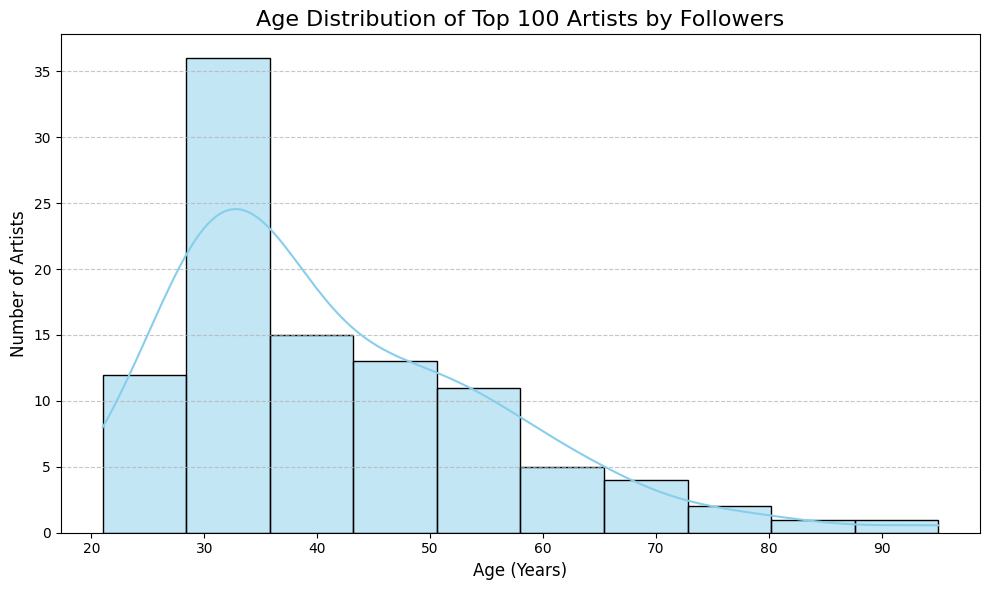


Visualization complete. A histogram showing the age distribution has been generated.


In [14]:
import pandas as pd
from rdflib import Graph, Namespace, Literal, XSD
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Define namespaces (must match those in your .ttl file)
SPOTIFY = Namespace("http://example.org/spotify/")
WDT = Namespace("http://www.wikidata.org/prop/direct/")
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")
WD = Namespace("http://www.wikidata.org/entity/")

# Load the knowledge graph from the TTL file
g = Graph()
try:
    g.parse("knowledge_graph_group6.ttl", format="turtle")
    print("Knowledge graph loaded successfully.")
except Exception as e:
    print(f"Error loading knowledge graph: {e}")
    # Exit if the graph cannot be loaded, as subsequent steps will fail
    exit()

# SPARQL query to get the top 100 artists by followers with their birth dates
# and labels.
query = """
SELECT ?artistName ?birthDate ?followers
WHERE {
  ?artist a wd:Q5 ; # Assuming wd:Q5 represents a human/person (artist)
          rdfs:label ?artistName ;
          wdt:P569 ?birthDate ;
          spotify:followers ?followers .
  FILTER (DATATYPE(?birthDate) = xsd:date) # Ensure birthDate is a date type
  FILTER (isLiteral(?followers) && DATATYPE(?followers) = xsd:integer) # Ensure followers is an integer
}
ORDER BY DESC(?followers)
LIMIT 100
"""

print("\nExecuting SPARQL query...")
results = g.query(query)

# Process the results
data = []
current_date = datetime(2025, 5, 23) # Using today's date as per instructions

for row in results:
    artist_name = str(row.artistName)
    birth_date_str = str(row.birthDate)
    followers = int(row.followers)

    try:
        birth_date = datetime.strptime(birth_date_str, "%Y-%m-%d")
        # Calculate age
        age = current_date.year - birth_date.year - ((current_date.month, current_date.day) < (birth_date.month, birth_date.day))
        data.append({"artistName": artist_name, "birthDate": birth_date_str, "followers": followers, "age": age})
    except ValueError:
        print(f"Skipping artist '{artist_name}' due to invalid birth date format: {birth_date_str}")
        continue

if not data:
    print("No data found for the top 100 artists or issues in processing. Cannot create visualization.")
else:
    # Create a DataFrame for easier manipulation and visualization
    df = pd.DataFrame(data)

    print(f"\nFound {len(df)} artists for visualization.")
    print("\nSample of processed data:")
    print(df.head())

    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    sns.histplot(df['age'], bins=10, kde=True, color='skyblue', edgecolor='black')
    plt.title('Age Distribution of Top 100 Artists by Followers', fontsize=16)
    plt.xlabel('Age (Years)', fontsize=12)
    plt.ylabel('Number of Artists', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

    print("\nVisualization complete. A histogram showing the age distribution has been generated.")

Knowledge graph loaded successfully.

Executing SPARQL query...

Found 100 artists for visualization.

Sample of processed data:
      artistName   birthDate  followers  age  awardsCount
0  Ariana Grande  1993-06-26  375767079   31            6
1   Taylor Swift  1989-12-13   92346584   35           29
2      Lady Gaga  1986-03-28   84906261   39           33
3          Adele  1988-05-05   56615181   37           16
4    Alan Walker  1997-08-24   46800000   27            1

Aggregated data (Average Awards by Age Group):
  age_group  Average Awards Won
0       0-9                 NaN
1     10-19                 NaN
2     20-29            2.625000
3     30-39            3.250000
4     40-49            2.222222


C:\Users\Acer\AppData\Local\Temp\ipykernel_20676\1206838665.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_awards_by_age_group = df.groupby('age_group')['awardsCount'].mean().reset_index()
C:\Users\Acer\AppData\Local\Temp\ipykernel_20676\1206838665.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='Average Awards Won', data=avg_awards_by_age_group, palette='viridis')


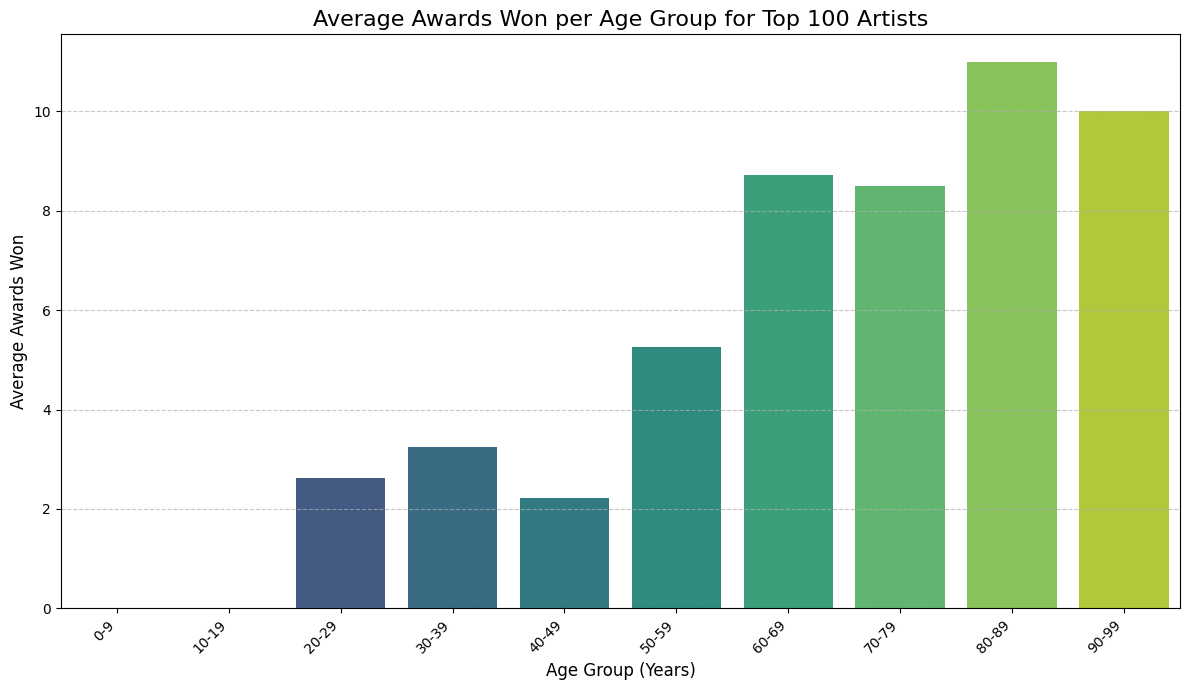

In [15]:
import pandas as pd
from rdflib import Graph, Namespace, Literal, XSD
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Define namespaces (must match those in your .ttl file)
SPOTIFY = Namespace("http://example.org/spotify/")
WDT = Namespace("http://www.wikidata.org/prop/direct/")
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")
WD = Namespace("http://www.wikidata.org/entity/")

# Load the knowledge graph from the TTL file
g = Graph()
try:
    g.parse("knowledge_graph_group6.ttl", format="turtle")
    print("Knowledge graph loaded successfully.")
except Exception as e:
    print(f"Error loading knowledge graph: {e}")
    # Exit if the graph cannot be loaded, as subsequent steps will fail
    exit()

# SPARQL query to get the top 100 artists by followers, their birth dates,
# and the count of awards they have received.
# OPTIONAL is used for awards so artists without awards are still included with an award count of 0.
query = """
SELECT ?artistName ?birthDate ?followers (COUNT(?award) AS ?awardsCount)
WHERE {
  ?artist a wd:Q5 ; # Assuming wd:Q5 represents a human/person (artist)
          rdfs:label ?artistName ;
          wdt:P569 ?birthDate ;
          spotify:followers ?followers .
  OPTIONAL { ?artist wdt:P166 ?award . } # wdt:P166 is 'award received'
  FILTER (DATATYPE(?birthDate) = xsd:date) # Ensure birthDate is a date type
  FILTER (isLiteral(?followers) && DATATYPE(?followers) = xsd:integer) # Ensure followers is an integer
}
GROUP BY ?artist ?artistName ?birthDate ?followers
ORDER BY DESC(?followers)
LIMIT 100
"""

print("\nExecuting SPARQL query...")
results = g.query(query)

# Process the results
data = []
current_date = datetime(2025, 5, 23) # Using today's date (May 23, 2025)

for row in results:
    artist_name = str(row.artistName)
    birth_date_str = str(row.birthDate)
    followers = int(row.followers)
    awards_count = int(row.awardsCount) # Awards count will be 0 if no awards in OPTIONAL

    try:
        birth_date = datetime.strptime(birth_date_str, "%Y-%m-%d")
        # Calculate age
        age = current_date.year - birth_date.year - ((current_date.month, current_date.day) < (birth_date.month, birth_date.day))
        data.append({
            "artistName": artist_name,
            "birthDate": birth_date_str,
            "followers": followers,
            "age": age,
            "awardsCount": awards_count
        })
    except ValueError:
        print(f"Skipping artist '{artist_name}' due to invalid birth date format: {birth_date_str}")
        continue

if not data:
    print("No data found for the top 100 artists or issues in processing. Cannot create visualization.")
else:
    # Create a DataFrame for easier manipulation and visualization
    df = pd.DataFrame(data)

    print(f"\nFound {len(df)} artists for visualization.")
    print("\nSample of processed data:")
    print(df.head())

       # Define age bins and labels for grouping
    min_age = df['age'].min()
    max_age = df['age'].max()
    # Create bins that cover the entire age range, in 10-year increments
    bins = list(range(0, max_age + 10, 10))
    labels = [f"{i}-{i+9}" for i in bins[:-1]] # Labels like "0-9", "10-19", etc.

    # Ensure labels match the number of bins - 1
    if len(labels) > len(bins) - 1:
        labels = labels[:len(bins)-1]
    elif len(labels) < len(bins) - 1:
        # If max_age is, say, 23, bins could be [0, 10, 20, 30], labels ['0-9', '10-19', '20-29']
        # pd.cut might create an extra bin if max_age falls exactly on a bin edge,
        # or if the last bin is not fully covered by labels.
        # This handles cases where the last bin might be e.g., 30-39 but max_age is 32.
        # We ensure the last label covers up to the max_age.
        labels.append(f"{bins[-2]}-{max_age}")


    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False, include_lowest=True)

    # Aggregate data: Calculate average awards won by age group
    avg_awards_by_age_group = df.groupby('age_group')['awardsCount'].mean().reset_index()
    avg_awards_by_age_group.rename(columns={'awardsCount': 'Average Awards Won'}, inplace=True)

    # Sort the age groups for better visualization order
    avg_awards_by_age_group['age_group'] = pd.Categorical(avg_awards_by_age_group['age_group'], categories=labels, ordered=True)
    avg_awards_by_age_group = avg_awards_by_age_group.sort_values('age_group')


    print("\nAggregated data (Average Awards by Age Group):")
    print(avg_awards_by_age_group.head())

    # --- Visualization: Average Awards Won per Age Group (Bar Plot) ---
    plt.figure(figsize=(12, 7))
    sns.barplot(x='age_group', y='Average Awards Won', data=avg_awards_by_age_group, palette='viridis')
    plt.title('Average Awards Won per Age Group for Top 100 Artists', fontsize=16)
    plt.xlabel('Age Group (Years)', fontsize=12)
    plt.ylabel('Average Awards Won', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=10, rotation=45, ha='right') # Rotate labels for readability
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()


Knowledge graph loaded successfully.

Executing SPARQL query...

Found 100 artists for visualization.

Sample of processed data:
      artistName   birthDate  followers  age  awardsCount
0  Ariana Grande  1993-06-26  375767079   31            6
1   Taylor Swift  1989-12-13   92346584   35           29
2      Lady Gaga  1986-03-28   84906261   39           33
3          Adele  1988-05-05   56615181   37           16
4    Alan Walker  1997-08-24   46800000   27            1

Aggregated data (Average Awards by Age):
   age  Average Awards Won
0   21                 1.0
1   22                 0.0
2   23                30.0
3   24                 0.5
4   26                 0.0


C:\Users\Acer\AppData\Local\Temp\ipykernel_20676\2359840655.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age', y='Average Awards Won', data=avg_awards_by_age, palette='viridis')


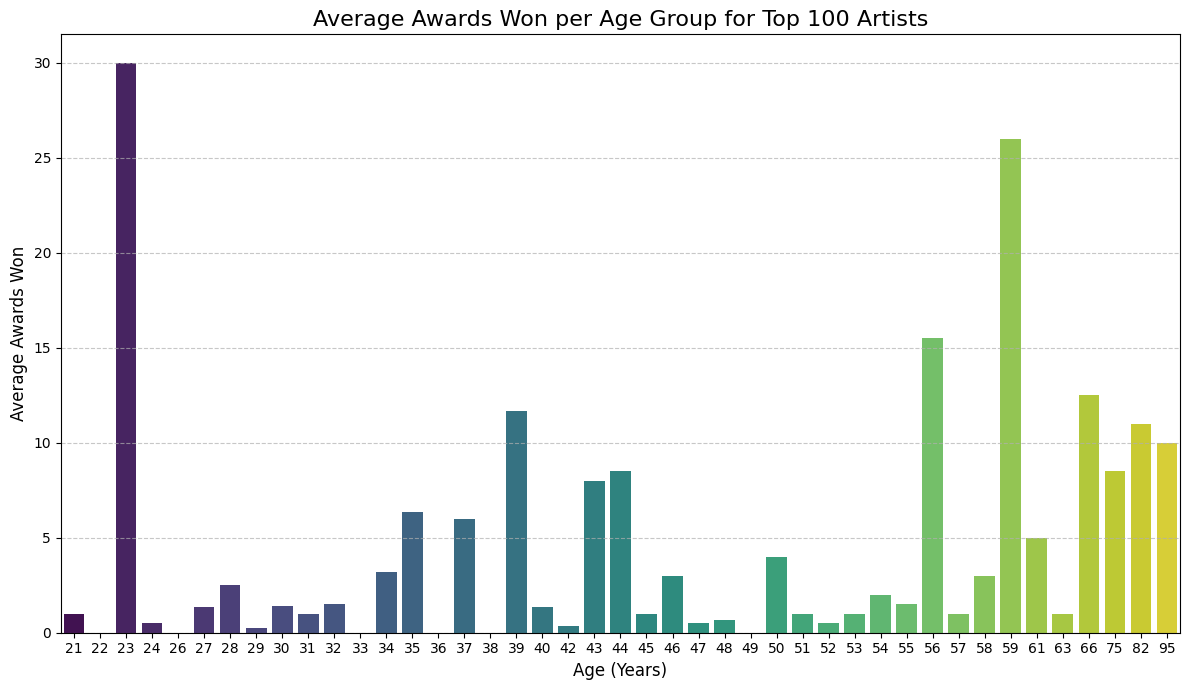


Visualization complete. A bar plot showing the average awards won per age group has been generated.


In [16]:
import pandas as pd
from rdflib import Graph, Namespace, Literal, XSD
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Define namespaces (must match those in your .ttl file)
SPOTIFY = Namespace("http://example.org/spotify/")
WDT = Namespace("http://www.wikidata.org/prop/direct/")
RDFS = Namespace("http://www.w3.org/2000/01/rdf-schema#")
WD = Namespace("http://www.wikidata.org/entity/")

# Load the knowledge graph from the TTL file
g = Graph()
try:
    g.parse("knowledge_graph_group6.ttl", format="turtle")
    print("Knowledge graph loaded successfully.")
except Exception as e:
    print(f"Error loading knowledge graph: {e}")
    # Exit if the graph cannot be loaded, as subsequent steps will fail
    exit()

# SPARQL query to get the top 100 artists by followers, their birth dates,
# and the count of awards they have received.
# OPTIONAL is used for awards so artists without awards are still included with an award count of 0.
query = """
SELECT ?artistName ?birthDate ?followers (COUNT(?award) AS ?awardsCount)
WHERE {
  ?artist a wd:Q5 ; # Assuming wd:Q5 represents a human/person (artist)
          rdfs:label ?artistName ;
          wdt:P569 ?birthDate ;
          spotify:followers ?followers .
  OPTIONAL { ?artist wdt:P166 ?award . } # wdt:P166 is 'award received'
  FILTER (DATATYPE(?birthDate) = xsd:date) # Ensure birthDate is a date type
  FILTER (isLiteral(?followers) && DATATYPE(?followers) = xsd:integer) # Ensure followers is an integer
}
GROUP BY ?artist ?artistName ?birthDate ?followers
ORDER BY DESC(?followers)
LIMIT 100
"""

print("\nExecuting SPARQL query...")
results = g.query(query)

# Process the results
data = []
current_date = datetime(2025, 5, 23) # Using today's date (May 23, 2025)

for row in results:
    artist_name = str(row.artistName)
    birth_date_str = str(row.birthDate)
    followers = int(row.followers)
    awards_count = int(row.awardsCount) # Awards count will be 0 if no awards in OPTIONAL

    try:
        birth_date = datetime.strptime(birth_date_str, "%Y-%m-%d")
        # Calculate age
        age = current_date.year - birth_date.year - ((current_date.month, current_date.day) < (birth_date.month, birth_date.day))
        data.append({
            "artistName": artist_name,
            "birthDate": birth_date_str,
            "followers": followers,
            "age": age,
            "awardsCount": awards_count
        })
    except ValueError:
        print(f"Skipping artist '{artist_name}' due to invalid birth date format: {birth_date_str}")
        continue

if not data:
    print("No data found for the top 100 artists or issues in processing. Cannot create visualization.")
else:
    # Create a DataFrame for easier manipulation and visualization
    df = pd.DataFrame(data)

    print(f"\nFound {len(df)} artists for visualization.")
    print("\nSample of processed data:")
    print(df.head())

    # Aggregate data: Calculate average awards won by age
    # We'll group by age and then calculate the mean of awardsCount for each age.
    # Reset index to make 'age' a regular column for plotting.
    avg_awards_by_age = df.groupby('age')['awardsCount'].mean().reset_index()
    avg_awards_by_age.rename(columns={'awardsCount': 'Average Awards Won'}, inplace=True)

    print("\nAggregated data (Average Awards by Age):")
    print(avg_awards_by_age.head())

    # --- Visualization: Average Awards Won per Age Group (Bar Plot) ---
    plt.figure(figsize=(12, 7))
    sns.barplot(x='age', y='Average Awards Won', data=avg_awards_by_age, palette='viridis')
    plt.title('Average Awards Won per Age Group for Top 100 Artists', fontsize=16)
    plt.xlabel('Age (Years)', fontsize=12)
    plt.ylabel('Average Awards Won', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

    print("\nVisualization complete. A bar plot showing the average awards won per age group has been generated.")


Executing SPARQL query to get top 100 artist URIs...

Executing SPARQL query for genres of top 100 artists...

Genre distribution for Top 100 Artists:
              Genre  Artist Count
0         pop music            40
1  contemporary R&B            20
2           hip-hop            14
3              soul            10
4         dance-pop            10


C:\Users\Acer\AppData\Local\Temp\ipykernel_20676\3560916072.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Artist Count', y='Genre', data=genre_counts.head(20),


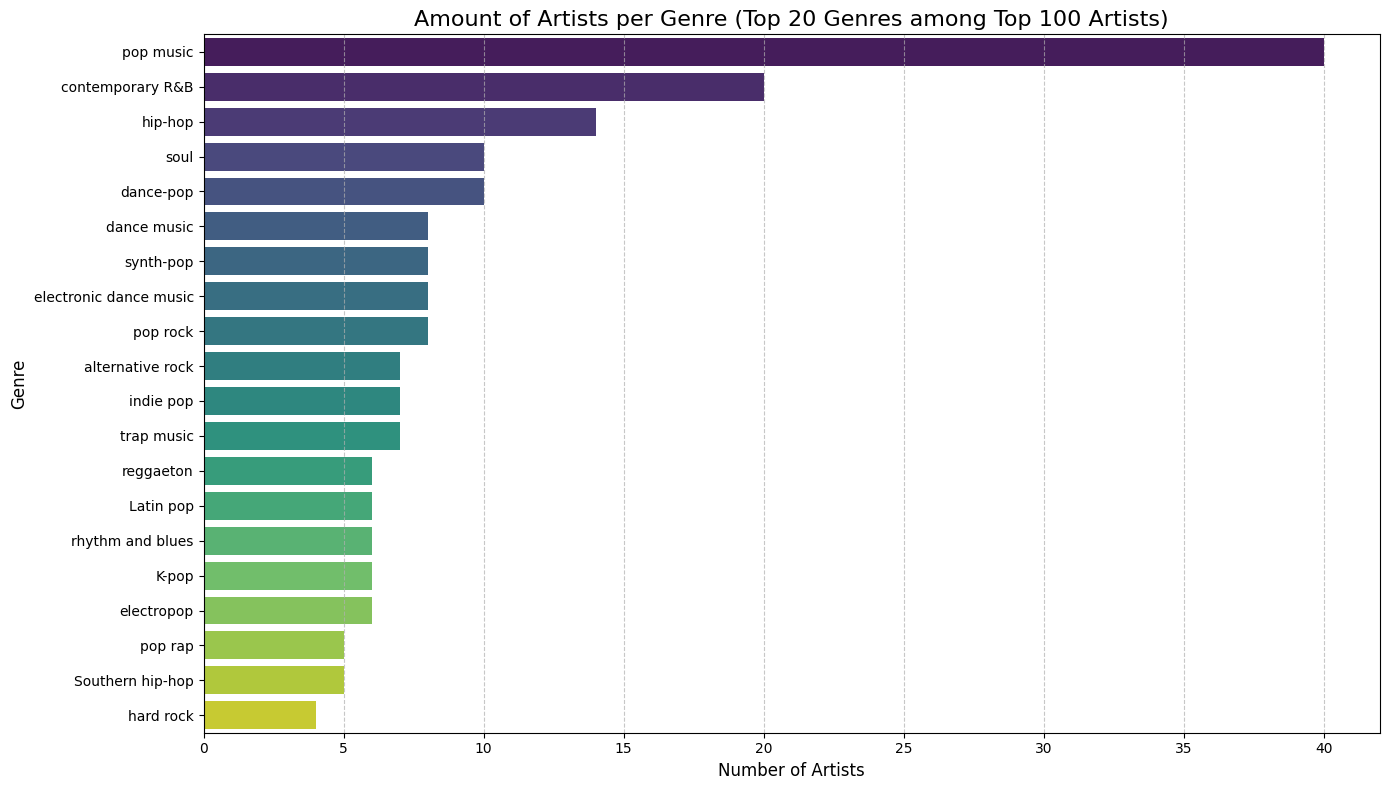


Visualization complete. A bar plot showing the amount of artists per genre has been generated.


In [17]:

# First, get the URIs of the top 100 artists by followers
query_top_100_uris = """
SELECT ?artist
WHERE {
  ?artist a wd:Q5 ; # Assuming wd:Q5 represents a human/person (artist)
          spotify:followers ?followers .
  FILTER (isLiteral(?followers) && DATATYPE(?followers) = xsd:integer)
}
ORDER BY DESC(?followers)
LIMIT 100
"""

print("\nExecuting SPARQL query to get top 100 artist URIs...")
top_100_uris_results = g.query(query_top_100_uris)
top_100_uris = [str(row.artist) for row in top_100_uris_results]

if not top_100_uris:
    print("No top 100 artists found to analyze genres.")
else:
    # Convert list of URIs to a VALUES clause for the next query
    values_clause = "VALUES ?artist { " + " ".join(f"<{uri}>" for uri in top_100_uris) + " }"

    # Now, query for the genres of these specific top 100 artists
    query_genres = f"""
    SELECT ?artistName ?genre
    WHERE {{
      {values_clause}
      ?artist rdfs:label ?artistName ;
              wdt:P136 ?genre . # wdt:P136 is 'musical genre'
    }}
    """
    print("\nExecuting SPARQL query for genres of top 100 artists...")
    results_genres = g.query(query_genres)

    all_genres = []
    for row in results_genres:
        genre = str(row.genre)
        all_genres.append(genre)

    if not all_genres:
        print("No genre data found for the top 100 artists.")
    else:
        # Count the occurrences of each genre
        genre_counts = pd.Series(all_genres).value_counts().reset_index()
        genre_counts.columns = ['Genre', 'Artist Count']

        print("\nGenre distribution for Top 100 Artists:")
        print(genre_counts.head())

        # --- Visualization: Amount of Artists per Genre (Bar Plot) ---
        plt.figure(figsize=(14, 8))
        # Apply the new color palette here
        sns.barplot(x='Artist Count', y='Genre', data=genre_counts.head(20),
                    palette=sns.color_palette("viridis", n_colors=len(genre_counts.head(20)))) # Changed palette to Reds_d
        plt.title('Amount of Artists per Genre (Top 20 Genres among Top 100 Artists)', fontsize=16)
        plt.xlabel('Number of Artists', fontsize=12)
        plt.ylabel('Genre', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        plt.tight_layout()
        plt.show()

        print("\nVisualization complete. A bar plot showing the amount of artists per genre has been generated.")
